# Demonstration: MNIST Digit Classification with TensorFlow 2.x

#Scenario:

- Ana is a data science student exploring deep learning for the first time. She’s heard about TensorFlow 2.x and decides to build a digit classifier using the MNIST dataset. This notebook documents her journey as she gradually builds up her model—starting simple, then improving it layer by layer, learning concepts like Dropout, optimizers, and overfitting along the way.

##Dataset Description:
- The MNIST (Modified National Institute of Standards and Technology) dataset is a benchmark dataset in machine learning and computer vision. It contains 70,000 grayscale images of handwritten digits (0 through 9), each of size 28x28 pixels.

- pixel value is btw [0, 255]
- 0: black
- 255: white
-  shade of gray

    - Training Set: 60,000 images

    - Test Set: 10,000 images

    - Format: Each image is a 28×28 pixel matrix, flattened into a vector of 784 features.

    - Labels: Each image is labeled with the correct digit (0–9).

- **Purpose:** MNIST is widely used for evaluating image classification models. Its simplicity makes it ideal for learning and testing neural networks, particularly in educational and research contexts.

In [ ]:
28*28

784

## Step 1: Import Required Libraries

In [ ]:
import tensorflow as tf #open source framework, used for training and building DL models, developed google
from tensorflow.keras.datasets import mnist #keras: high level deep learning api build on top of tensorflow => fewer lines of code
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Load the MNIST Dataset

In [ ]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data() #mnist...module ...load_data (function)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
type(X_train) #numpy array

numpy.ndarray

In [ ]:
X_train.ndim

3

In [ ]:
X_train.shape #numpy array
#60000 images of size 28*28

(60000, 28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
X_train.shape #1st dim image

(60000, 28, 28)

In [ ]:
X_train[5] #grayscale image means black and white image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  13,  25, 100, 122,   7,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         33, 151, 208, 252, 252, 252, 146,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  40, 152,
        244, 252, 253, 224, 211, 252, 232,  40,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  15, 152, 239, 252,
        252, 252, 216,  31,  37, 252, 252,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  96, 252, 252, 252,
        252, 217,  29,   0,  37, 252, 252,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 181, 252, 252, 220,
        167,  30,   0,   0,  77, 252, 252,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  26, 128,  58,  22,
          0,   0,   0,   0, 100, 252, 252,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 157, 252, 252,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        110, 121, 122, 121, 202, 252, 194,   3,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10,  53, 179,
        253, 253, 255, 253, 253, 228,  35,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   5,  54, 227, 252, 243,
        228, 170, 242, 252, 252, 231, 117,   6,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   6,  78, 252, 252, 125,  59,
          0,  18, 208, 252, 252, 252, 252,  87,   7,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   5, 135, 252, 252, 180,  16,   0,
         21, 203, 253, 247, 129, 173, 252, 252, 184,  66,  49,  49,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   3, 136, 252, 241, 106,  17,   0,  53,
        200, 252, 216,  65,   0,  14,  72, 163, 241, 252, 252, 223,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 105, 252, 242,  88,  18,  73, 170, 244,
        252, 126,  29,   0,   0,   0,   0,   0,  89, 180, 180,  37,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 231, 252, 245, 205, 216, 252, 252, 252,
        124,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 207, 252, 252, 252, 252, 178, 116,  36,
          4,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  13,  93, 143, 121,  23,   6,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
y_train[5] # what is 5?5 is index...6th image

np.uint8(2)

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
#X_train[1]#2nd image

In [ ]:
y_train.shape

(60000,)

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
X_test.shape #10,000 images of size 28*28

(10000, 28, 28)

## Step 3: Visualize a Sample Image

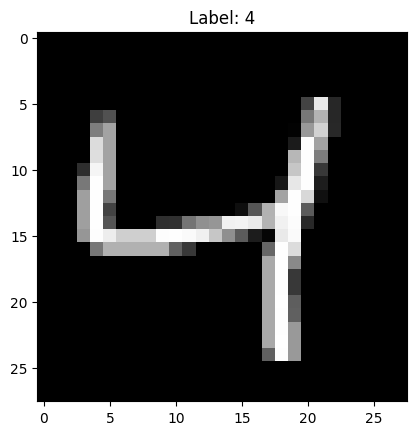

In [ ]:
plt.imshow(X_train[2], cmap='gray') #imshow -> displays the image
plt.title(f"Label: {y_train[2]}")
plt.show()

## Step 4: Normalize and Flatten the Data

In [ ]:
X_train.shape # (60000, 784)

(60000, 28, 28)

X_train -> (60000, 28, 28) -> (60000, 784)
X_train.reshape(-1, 28*28) -> 2 dim

Original array shape: (60000, 28, 28)
Reshaped array shape: (x, 784)

x*784 = 60000*28*28
x = 60000*28*28/784 = 60000

In [ ]:
#60000 28 28 -> 60000 784
X_train = X_train.reshape(60000, 784).astype('float32') / 255.0
#scaling 0-> 0, scaling 255->1...any pixel value btw 0 and 255 will be accordingly scaled btw 0 and 1
X_test = X_test.reshape(10000, 784).astype('float32') / 255.0

#why are we scaling (why we have to divide by 255)
#faster convergence
#pixel value ->0-255
# 255 ->1


In [ ]:
#X_train[0]

## Step 5: One-Hot Encode Labels

### What are we expecting in the output layer of the neural network

Probabilities [P(0) P(1)...........P(9)]

prdicted value = [0.01 0.0.......0.89]

Actual value = labels = 9

Loss -> how off our prediction is from true value

Actual value = labels = 9

[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


**Label 2**

Prob -> 0 and 1
P(0) + P(1)....+P(9) = 1
true value (2) = [P(0) P(1) P(2)......P(9)]
            [0 0 1 0.....0]


label = 2
[P(0), P(1), P(2),......P(9)]

[0, 0, 1, 0,0, 0, 0,...]

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10) #10 classes (digits from 0 to 9) -> vector of size 10 in ouput
y_test = to_categorical(y_test, 10)

In [ ]:
y_train.shape, y_test.shape

((60000, 10), (10000, 10))

In [ ]:
y_train[0] #label was 5

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
y_train[0] #actual label was 5 -> when we convert it vector of prob [p(0), p(1), .......p(9)]
#prob -> 0 and 1
#0 -> 0 chance of an event happening
#1  -> 100% chance of an event happening
#100% chance that the first digit is 5
# sum of these prob p(0)+p(1)+p(2)....+p(9) = 1

p(4), p(1), ....

SyntaxError: invalid syntax (684769759.py, line 8)

In [ ]:
6

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

In [ ]:
#X_train[3]

In [ ]:
y_train[3]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
1. loaded the mnist data from keras
2. flattened the data (2 dimension (28*28) -> 1 dimension(784)): for flattening the data we used reshape function of numpy
3. normalized the data for fast convergence : /255 [pixel values were btw 0-255 -> 0-1]
3. we convered labels tp vector of prob [ouput of neural network is probabilities...to compare predicted value with actual value [apple to apple comparion]-> prob]

DATA READY

## Step 6: Build a Basic Sequential Model

In [ ]:
from tensorflow.keras.models import Sequential #class
from tensorflow.keras.layers import Dense, Dropout, Activation, Input

In [ ]:
#defining the architecture of our NN
model_basic = Sequential() #allows us to build the neural network layer by layer
#Input layer -> hidden layer -> output layer
model_basic.add(Dense(64, activation='relu', input_shape=(784,))) #1st hidden layer...64 neurons, bt can we can keep any number
#can different neurons in same hidden layer have differnt activation functions
model_basic.add(Dense(10, activation='softmax')) #output layer -> 10 classes -> 10 prob [digits from 0 to 9]
# The softmax activation function is used in the output layer of a neural network when the task is multi class classification
#can activation function in output layer be RELU
# softmax -> 0 and 1
# gives prob in the output -> sum to 1
#P(0) + P(1)+..... = 1
#f(z) = e^z/sum(e^z) for all z

#binary classification -> sigmoid (sppam/not spam) (positive/ negative)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 7: Compile the Basic Model with SGD

In [ ]:
#sgd -> stochastic gradient descent -> adjust the weights so that loss is minimized
#loss function -> MSE, MAE ->quantify the performance....measure how far the model prediction is from the true value
#categorical_crossentropy -> multi class classification problems
#we can also set learning rate in compile, if we dont expliciltly specify learning rate it takes default learning rate
#adam ->.001
#SGD -> .01
model_basic.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [50]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=.02)
model_basic.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#loss

**stochastic gradient descent** -> updates the weight in direction which reduces the **loss**

**categorical_crossentropy** -> multi class classification where in output you are getting probabilities

How does the calculation works?

**predicted values**
P(0) = 0.7 #70% sure it is zero -> loss -> high 0.9 -> model is more sure -> LOSS is smaller number
P(1) = 0.0
P(2) = 0.0
P(3)= 0.3
.....P(9) =0

**True value**
P(0) = 1
P(1)...P(9) = 0

Formulae for categorical_crossentropy

loss = -sum for all the classes(p_true_class[i] * log(p_pred_class[i]))
    = -(1*log(0.7) + 0*log(0.1) + 0*log(0.2)....)


In [ ]:
import math
math.log(0.7)

-0.35667494393873245

In [ ]:
math.log(0.8)

-0.2231435513142097

## Step 8: Train the Basic Model

**What does training the model means??**

Learn the params -> weight and biases
such that loss is reduced

**epoch** -> one complete pass through the entire training dataset [6000 images]

EPOCH = 10

Training data = 60,000 images

during the training the model will go over each image how many times? -> 10

1st epoch: look at all the 60,000 images -> once -> 1st epoch

2nd epoch: look at same set of 60,000 images again -> 2nd epoch

....10 epoch

it sees data more times -> learns better

but if too many epochs -> take lot of time and resources to train the model; risk of overfitting [example -100% accuracy on training data and only 80% acc on test data -> overfittig]


#### Batch Size

**batch_size** -> no. of training samples the model processes before updating its weight once (backward propgation)

batch_size=1 -> after every image model will update its weight based on loss function [1st image -> pred -> loss for this first image-> backward pass -> weights will be updated; 2nd image]

batch_size=2 -> after every 2 images model will update its weight based on loss function [1st image -> pred1(e1); 2nd image -> pred2(e2)....loss for both images (e1+e2) -> backward pass and update the weights]

batch_size=32 -> after every 32 images model will update its weights based on the loss function

1st image -> pred 1
2nd image -> pred 2
.....
32 image -> pred 32

loss = sum of loss of 32 images

backward pass....params will be updated so that the loss is reduced

33rd image -> pred 33 [forward pass]
34 image -> 34 pred

...
64 image -> 64 pred

loss = sum of loss of 32 images (33rd image to 64th image)
backward pass

1st epoch -> how many times weights of the NN are updated, given the batch size is 32?

* how many batches of images of size 32 = 60000/32 = 1875 batches
* how many times loss would be calculated -> 1875 times
* how many times backward pass -> 1875....weights would be updated 1875 times in one epoch

Total no. of times weight is updated
10 epochs * 1875/epoch weight updates = 18,750 times

**Affect of batch size on memory usage and speed**

small batch -> slower (updating weights frequently) but generalise better

large batch -> faster but maybe not learn v well

### How the training happens

1st image  -> prediction  - actual = loss (batch size) -> backward pass -> update the weigth ....weights are updated such that loss is minimised


32 image = sum of loss for 32 images -> backward pass -> update the weigth ....weights are updated such that loss is minimised

In [ ]:
X_train.shape

(60000, 784)

In [ ]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
#Let the model look at the same training data 10 times , updating itself a little bit each time

#20th epoch accuracy  > 21st epoch accuracy -> 22nd epoch

In [ ]:
#train the model -> fit SUPERVISED LEARNING MODELS -> Features AND Labels
history_basic = model_basic.fit(X_train, y_train, epochs=10, batch_size=32,shuffle=True) #ny number
#X_train -> image (pixel values)
#Y_train -> vector of prob -> loss -> weights would be updated

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8334 - loss: 0.6613
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9022 - loss: 0.3485
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9148 - loss: 0.3021
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2715
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9311 - loss: 0.2475
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9356 - loss: 0.2278
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9405 - loss: 0.2119
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9442 - loss: 0.1987
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9469 - loss: 0.1876
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9496 - loss: 0.1777


In [ ]:
#Accuracy -> % of correct predictions
#loss -> how wroing the model is based on loss function (cross entropy) (not percent) [0 and inf]

#Accuracy can be low because of multiple reasons

1. data -> pattern -> dl unearth
2. training data is not sufficient or quality of data is not good,
biased and unbalanced, mnist -> 90% of image are of digit 8
3. insufficient training [epochs, batch size]
4. choice of model [more hidden layers, more neurons]
5. Overfitting

## Step 9: Evaluate Basic Model

In [ ]:
loss_basic, acc_basic = model_basic.evaluate( X_test, y_test) #unseen data -> y_pred
print(f"Basic Model Accuracy: {acc_basic:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9503 - loss: 0.1720
Basic Model Accuracy: 0.9503


## Step 10: Add an Additional Hidden Layer

In [ ]:
model_deep = Sequential([
    Dense(128, activation='relu', input_shape=(784,)), #1st hidden; has 128 neurons, # 2^n
    #what is output size of 1st hidden layer  -> 128
    Dense(64, activation='relu'), #2nd hidden has 64 neurons
    #Why am i not specifing the input shape in 2nd hidden layer -> bec the size of input = size of output of prev layer
    Dense(10, activation='softmax') #output layer
])

In [ ]:
128 * 785

100480

In [ ]:
1st hidden layer

1 neuron -> 784 inputs -> 784 weights + bias term = 785 param

128 * 785 (100480)

2nd hidden layer

1 neuron -> 128 inputs -> 128 weights + bias term = 129 param

64 * 129 (82944)

In [ ]:
#how many weights are to be learned in second hidden layer
#1 neuron -> 128 inputs (from prev layer) -> 128 correposnding weights + bias term = 129 param
64 *129

8256

In [ ]:
import math
math.pow(2, 7)

128.0

## Step 11: Compile Deeper Model

In [ ]:
model_deep.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

## Step 12: Train Deeper Model

In [ ]:
history_deep = model_deep.fit(X_train, y_train, epochs=10, batch_size=32, shuffle=True) #which images go in a batch are randomly selected

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8336 - loss: 0.6259
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9130 - loss: 0.3029
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9280 - loss: 0.2511
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9384 - loss: 0.2152
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9462 - loss: 0.1881
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9518 - loss: 0.1673
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9570 - loss: 0.1506
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9600 - loss: 0.1371
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9635 - loss: 0.1256
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9668 - loss: 0.1158


## Step 13: Evaluate Deeper Model

In [ ]:
loss_deep, acc_deep = model_deep.evaluate(X_test, y_test) #unseen test data
print(f"Deeper Model Accuracy: {acc_deep:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9634 - loss: 0.1204
Deeper Model Accuracy: 0.9634


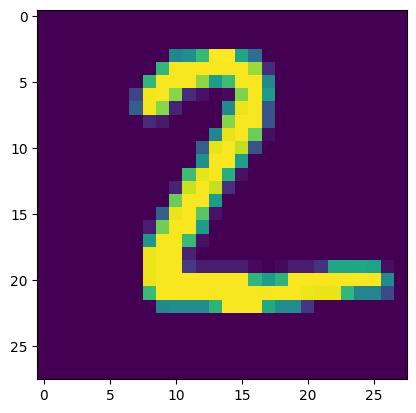

In [ ]:
plt.imshow(X_test[1].reshape(28,28)) #original image

In [ ]:
predictions = model_deep.predict(X_test[0:2]) #10k images (uinseen images - first to images...i am asking model to do the prediction based on weights learned

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [ ]:
predictions.shape

(2, 10)

In [ ]:
predictions[1] #output for 1st image -> prob of digits 0 to 9

array([2.9854407e-05, 2.2545210e-04, 9.8629504e-01, 1.0301156e-02,
       1.4927886e-08, 2.6763962e-03, 3.0305423e-04, 8.9432755e-09,
       1.6893362e-04, 1.6349069e-09], dtype=float32)

In [ ]:
predictions[1].argmax() # taking out the one with max probdigit is 7

np.int64(2)

In [ ]:
predictions[0].max()

np.float32(0.99433446)

## Step 14: Add Dropout Layers

Regularization technique -> reduce overfitting

**How to know if model is overfitting:** Model is performing well on training data [98%] but not so well on testing/unseen data [70%]-> overfitting

To fix this overfitting we can **add dropout layer**-> randomly drops/ turns off fraction of neurons during training(20%, 50%)

Turning off some neurons during the training
The idea is we dont want the model t**o heavily rely on any particular neuron**

**during training**

1. Every time the  model sees a batch of data (i.e a forward pass)
2. Dropout randomly selected neurosn and set their  output to 0

1st hidden layer there are 5 neurons
n1 n2 n3 n4 n5

1st fwd pass: n1 n3 n4 (switched off n2 and n5)

2nd fwd pass: n3 n2 n5

Dropout is only active during TRAIning. Once training is compelted and you do the prediction using trained model...all the neurons will be used for prediction

dropout is not always needed:

1. training dataset is huge/varied
2. model is not overfitting

In [ ]:
from prompt_toolkit.filters import has_suggestion

Exam -> help of your friends

day1 -> Aryan -> Maths

day2 -> aryan is absent, so u shd take help from someone else or rely on urself

day3...

In [ ]:
model_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.3), #Drop 30% of neurons randomly during training
    Dense(64, activation='relu'), #2nd hidden
    Dropout(0.2),#Drop 20% of neurons randomly during training
    Dense(10, activation='softmax') #output layer
])

In [ ]:
cv2.im_read(path of your file.jpg)
28, 28

black white

1 dim -> scale -> /255

good to feed in the model to get the preedictions


## Step 15: Compile Model with Adam Optimizer

In [ ]:
model_dropout.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

## Step 16: Train Model with Dropout + Adam

In [ ]:
60000

6000: validation purpose

In [ ]:
54000/32

1687.5

## Validation Split

We keep aside a portion of training data to check how well the model is learning

60000 training data -> 10% of data i am going to keep aside as vaidation data.....6000 ...no training will happen

60000 -6000 = 54,000 remaining dataset ...the training will happen....

6000....check performance of the model on unseen  data after each epoch....(training is underway and during the training itself we are chckin performance)

We are trying to test if model is learning general patterns or just memorising

Training Set -> studying from the book
Validation Set -> after each read solving practice problems
Test Set -> final exam

In [ ]:
54000/ 32

1687.5

In [ ]:
history_dropout = model_dropout.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)
#during the training you would like to know how model is performing on seen data vs unseen data

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7148 - loss: 0.9312 - val_accuracy: 0.9200 - val_loss: 0.3085
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8655 - loss: 0.4582 - val_accuracy: 0.9345 - val_loss: 0.2282
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8908 - loss: 0.3701 - val_accuracy: 0.9452 - val_loss: 0.1904
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9052 - loss: 0.3219 - val_accuracy: 0.9517 - val_loss: 0.1673
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9164 - loss: 0.2884 - val_accuracy: 0.9562 - val_loss: 0.1500
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9228 - loss: 0.2640 - val_accuracy: 0.9623 - val_loss: 0.1354
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9289 - loss: 0.2427 - val_accuracy: 0.9657 - val_loss: 0.1259
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9342 - loss: 0.2268 - 

## Step 17: Evaluate Dropout + Adam Model

In [ ]:
loss_dropout, acc_dropout = model_dropout.evaluate(X_test, y_test)
print(f"Improved Model Accuracy: {acc_dropout:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9617 - loss: 0.1298
Improved Model Accuracy: 0.9617


## Step 18: Compare Validation Accuracies

In [ ]:
history_deep.history

{'accuracy': [0.8335999846458435,
  0.913016676902771,
  0.9280333518981934,
  0.9384333491325378,
  0.9461833238601685,
  0.9517833590507507,
  0.95701664686203,
  0.9599666595458984,
  0.963533341884613,
  0.9667500257492065],
 'loss': [0.6258652806282043,
  0.3029024600982666,
  0.25109151005744934,
  0.2151561975479126,
  0.1880701631307602,
  0.16727304458618164,
  0.1506347358226776,
  0.1370634287595749,
  0.12555742263793945,
  0.11576966941356659]}

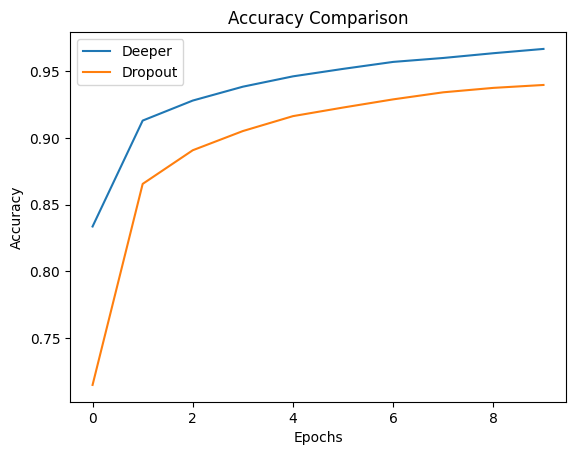

In [ ]:
#plt.plot(history_basic.history['val_accuracy'], label='Basic')
plt.plot(history_deep.history['accuracy'], label='Deeper')
plt.plot(history_dropout.history['accuracy'], label='Dropout')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Step 19: Predict on Test Data

In [ ]:
predictions = model_dropout.predict(X_test) #10k images
predicted_labels = np.argmax(predictions, axis=1) #returns index of max value

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predictions = model_dropout.predict(X_test[0:2]) #10k images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [ ]:
predictions

array([[1.23836196e-06, 3.37687112e-07, 1.03731836e-04, 2.26584350e-04,
        8.49296242e-08, 5.78056233e-06, 1.07066986e-08, 9.99532580e-01,
        1.11763438e-06, 1.28471816e-04],
       [4.31750785e-04, 2.63042486e-04, 9.94496763e-01, 3.35408258e-03,
        1.30507624e-06, 2.36501175e-04, 4.53484361e-04, 1.40164066e-05,
        7.48843537e-04, 2.27735569e-07]], dtype=float32)

In [ ]:
predictions[0]

array([2.86362524e-06, 2.23884763e-06, 1.39081894e-04, 2.55539635e-04,
       4.93658661e-07, 2.55727082e-06, 5.95444316e-09, 9.99482095e-01,
       1.28287195e-06, 1.13756796e-04], dtype=float32)

In [ ]:
predicted_labels[0]

np.int64(7)

## Step 20: Visualize Sample Predictions

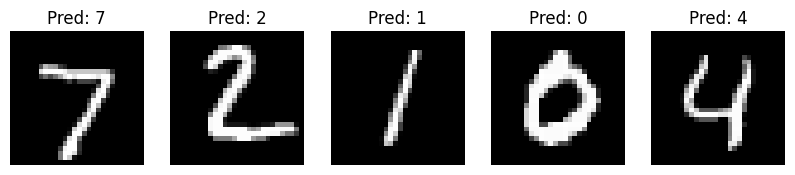

In [ ]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()

## Step 21: Visualize Training Losses

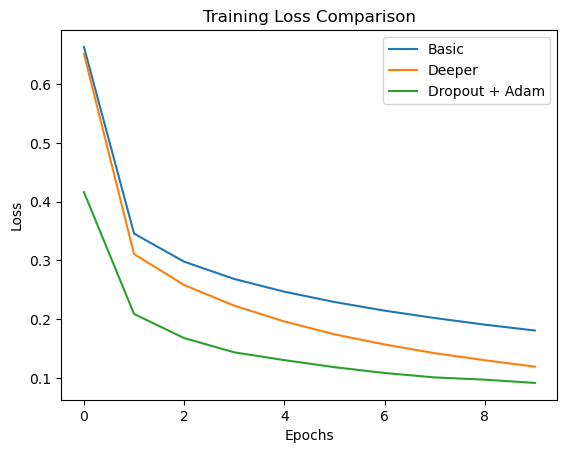

In [ ]:
plt.plot(history_basic.history['loss'], label='Basic')
plt.plot(history_deep.history['loss'], label='Deeper')
plt.plot(history_dropout.history['loss'], label='Dropout + Adam')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Step 22: Use .evaluate() to Evaluate Performance

In [ ]:
print(f"Loss on Test Set (Basic): {loss_basic:.4f}")
print(f"Loss on Test Set (Deeper): {loss_deep:.4f}")
print(f"Loss on Test Set (Dropout+Adam): {loss_dropout:.4f}")

Loss on Test Set (Basic): 0.1837
Loss on Test Set (Deeper): 0.1105
Loss on Test Set (Dropout+Adam): 0.1333


## Step 23: Summarize Models

In [ ]:
Each neuron -> 784 weights +1 bias = 785 params

total params = 64 neurons * 785

In [ ]:
64*785

50240

In [ ]:
1 neuron -> 64 weights + 1 bias = 65 parms

In [ ]:
print("\nBasic Model Summary:")
model_basic.summary()
print("\nImproved Model with Dropout Summar:")
model_dropout.summary()


Basic Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,892 (198.80 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


Improved Model with Dropout Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [ ]:
model_basic.save('basic_model.h5') #container file format->model architecture, model weights, conf

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('basic_model.h5')

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,892 (198.80 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[7.97335670e-05, 1.10679707e-07, 8.44707713e-04, ...,
        9.93929386e-01, 2.70127621e-05, 2.18366549e-04],
       [1.30591774e-03, 7.26057406e-05, 9.75299478e-01, ...,
        1.06534104e-09, 4.15216549e-04, 2.91748581e-09],
       [1.61354073e-05, 9.78803515e-01, 6.62434660e-03, ...,
        5.05937217e-03, 2.98064318e-03, 2.24247429e-04],
       ...,
       [1.38806172e-07, 4.01847046e-07, 1.32078949e-05, ...,
        1.52588473e-04, 2.29053362e-03, 1.20708225e-02],
       [2.91052384e-05, 4.15138638e-05, 1.56154583e-05, ...,
        6.23444475e-06, 6.32613152e-03, 1.96336186e-05],
       [1.58157618e-05, 1.33249065e-10, 5.48962016e-05, ...,
        4.64739053e-10, 8.27364602e-07, 1.76396231e-08]], dtype=float32)

In [ ]:
from PIL import Image
import numpy as np

img = Image.open("path of image/num2.jpg").convert('')

img = img/255 #(28, 28)

model.predict(img.reshape(1, 28*28)) #(60000, 784)

1. predicts temp tomorrow -> not
2. write poems -> yes
3. predict movie review sentiment -> no
4.